# Hispasonic — Supply & Demand Analysis

**Source:** `../data/processed/hispasonic_unified.csv`  
**Goal:** Determine the relationship between supply, demand, city and price in the second-hand synthesizer market  
**Figures:** Saved automatically to `../reports/figures/`

---

## Definitions

| Concept | Column(s) | Logic |
|---------|-----------|-------|
| **Supply** | `sell == 1` | Someone offers an item for sale |
| **Demand** | `buy == 1` or `search == 1` | Someone is actively looking to buy |
| **S/D ratio** | demand / supply | > 1 → more demand than supply (seller's market) |
| **Proxy demand** | `seen` | Total views — passive interest regardless of listing type |

**Hypothesis:** Cities with a high demand/supply ratio should show higher median sell prices.  
**Temporal hypothesis:** When the ratio rises in a city across scrape dates, prices should follow upward.

---

## Analysis plan
1. Imports and config
2. Load dataset
3. Supply and demand counts per city
4. Supply/demand ratio per city — ranking and price correlation
5. Temporal evolution of supply, demand and ratio per city
6. Price vs ratio scatter — does ratio predict price?
7. Supply/demand ratio over time — market tightness evolution
8. `seen` as passive demand proxy — city and brand breakdown
9. Summary findings

## 1. Imports and config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from scipy import stats

DATA_PATH   = '../data/processed/hispasonic_unified.csv'
FIGURES_DIR = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

TOP_N = 15
MIN_SUPPLY = 5  # minimum supply listings to include a city in ratio analysis

def savefig(name):
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    plt.savefig(path, dpi=150)
    print(f'Saved → {path}')
    plt.show()

print('Setup complete.')

Setup complete.


## 2. Load dataset

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['published', 'expire', 'date_scrapped'])

# Derived columns
df['is_supply'] = df['sell'].fillna(0).astype(int)
df['is_demand'] = ((df['buy'].fillna(0) + df['search'].fillna(0)) > 0).astype(int)

print(f'Shape: {df.shape}')
print(f'Supply listings: {df["is_supply"].sum():,}')
print(f'Demand listings: {df["is_demand"].sum():,}')
print(f'Scrape dates: {df["date_scrapped"].nunique()}')
print(f'Cities: {df["city"].nunique()}')

Shape: (5962, 19)
Supply listings: 5,480
Demand listings: 242
Scrape dates: 12
Cities: 49


``` 
Full Flow Brief

  Dataset
    │
    ├─ Columnas is_supply / is_demand
    │
    ├─ By city (estatic)
    │   ├─ Supply vs demand absolutos       [fig 19]
    │   ├─ Ranking ratio                    [fig 20]
    │   ├─ Ratio vs precio (scatter)        [fig 21]
    │   └─ Dual axis ratio + precio         [fig 22]
    │
    ├─ By city × time (dinamic)
    │   ├─ Supply and demand for scrape     [fig 23]
    │   ├─ Ratio por scrape                 [fig 24]
    │   └─ ¿Ratio(t) predictio price(t+1)?  [fig 27]
    │
    ├─ Global × time
    │   └─ Suppy, demand, ratio, price      [fig 25]
    │
    └─ Demanda pasiva (seen)
        └─ Seen vs price by city            [fig 26]
```

## 3. Supply and demand counts per city

In [3]:
# Aggregate by city
city_agg = df.groupby('city').agg(
    supply   = ('is_supply', 'sum'),
    demand   = ('is_demand', 'sum'),
    total    = ('is_supply', 'count'),
    med_price= ('price', 'median'),
    mean_seen= ('seen', 'mean')
).reset_index()

# Filter cities with enough supply to be meaningful
city_agg = city_agg[city_agg['supply'] >= MIN_SUPPLY].copy()

# Supply/demand ratio (demand per unit of supply)
city_agg['sd_ratio'] = (city_agg['demand'] / city_agg['supply'].replace(0, np.nan))*100

city_agg = city_agg.sort_values('total', ascending=False)

print(f'Cities with ≥{MIN_SUPPLY} supply listings: {len(city_agg)}')
city_agg.sort_values(by=["sd_ratio"], ascending=False).head(20)

Cities with ≥5 supply listings: 45


,city,supply,demand,total,med_price,mean_seen,sd_ratio
13,Ciudad Real,7,4,12,190.0,488.916667,57.142857
25,La Rioja,34,13,47,60.0,252.723404,38.235294
18,Gipuzkoa,50,18,72,27.5,472.083333,36.000000
7,Baleares,88,10,100,300.0,417.660000,11.363636
10,Burgos,9,1,10,400.0,967.800000,11.111111
1,Albacete,28,3,31,215.0,433.258065,10.714286
20,Granada,87,8,104,230.0,439.903846,9.195402
34,Ourense,33,3,36,300.0,432.861111,9.090909
31,Murcia,79,7,89,139.0,500.921348,8.860759
5,Asturias,70,6,80,100.0,461.075000,8.571429


The first thing that stands out is the **magnitude of the values** the values range from **57.14 to 3.33**. This indicates that you are measuring dispersion as a **direct percentage** (e.g., 57.14% variation).

The strategic analysis of what this sorting reveals about the markets:

### 1. Interpreting the Extremes

This sorting divides your markets into two very clear operational categories:

#### **🔴 High Volatility Zone (sd_ratio > 20%)**
*Ciudad Real (57%), La Rioja (38%), Gipuzkoa (36%)*

*   **What it means:** The market is **broken or highly fragmented**.
*   **The reality:** The "average" here **is meaningless**. In Ciudad Real, with 57% dispersion, it means there are zones or periods with a Supply/Demand equilibrium vastly different from other zones.
*   **The Risk:** If you make decisions based on the mean (`mean_seen`), you have a **57% probability of error** regarding the reality of a specific segment.
*   **Strategy:** You cannot launch a uniform national or regional campaign. You need **hyper-segmentation**. What works in the capital may not work in the province.

#### **🟢 Stability Zone (sd_ratio < 10%)**
*Madrid (3.49%), Valladolid (3.33%), Sevilla (5.8%)*

*   **What it means:** The market is **liquid and homogeneous**.
*   **The reality:** In Madrid, despite having the highest volume (1461 totals), the dispersion is minimal (3.49%). This indicates that the Supply/Demand relationship is consistent across almost all its districts.
*   **The Advantage:** The average data is **very reliable**. You can predict market behavior with high certainty.
*   **Strategy:** Ideal for **automation and scalable strategies**. A rule that works for the Madrid average will work for most of its zones.

---

### 2. Key Study Findings

By cross-referencing `sd_ratio` with volume (`total`), we obtain very valuable counterintuitive insights:

| Finding | Example Cities | Strategic Interpretation |
| :--- | :--- | :--- |
| **Volume ≠ Stability** | **Gipuzkoa** (72 totals, 36% var.) vs **Madrid** (1461 totals, 3.5% var.) | Having few data points doesn't always imply instability, but here we see that small markets can be chaotic, while massive markets (Madrid) can be very mature and balanced. |
| **High Prices + High Variance** | **Burgos** (400€ med_price, 11% var.) | Expensive but unstable markets. There is a risk of overvaluation in certain areas. Opportunity to find "bargains" if you know where to look. |
| **"Trap" Markets** | **Ciudad Real** (57% var.) | The Supply/Demand ratio is misleading. There could be a neighborhood with high demand and another dead one. If you invest here without analyzing by micro-zones, the risk is maximum. |

---

### 3. Decision Matrix for Your Study

You can use this sorting to create a simple **Strategy Matrix**:

| | **Low Supply/Demand (Niche)** | **High Supply/Demand (Massive)** |
| :--- | :--- | :--- |
| **HIGH `sd_ratio`**<br>*(Unstable)* | **DANGER ZONE**<br>*(Ex: Ciudad Real, La Rioja)*<br>⚠️ Avoid automatic strategies. Requires manual analysis zone by zone. High risk of error. | **OPPORTUNITY ZONE**<br>*(Ex: Valencia, Zaragoza)*<br>🚀 There is lots of activity but disordered. Arbitrage opportunity: bring supply where it is lacking. |
| **LOW `sd_ratio`**<br>*(Stable)* | **QUIET ZONE**<br>*(Ex: Valladolid, Jaén)*<br>💤 Predictable but small market. Good for maintenance, bad for explosive growth. | **IDEAL ZONE**<br>*(Ex: Madrid, Sevilla)*<br>✅ Mature market. Scalable, predictable and with volume. Ideal for investing massive resources. |

### 4. Technical Conclusion

The `sd_ratio` value in this study acts as a **confidence indicator for the average data**:

1.  **If `sd_ratio` > 20%:** Be wary of the `mean_seen`. The market is too irregular.
2.  **If `sd_ratio` < 10%:** Trust the `mean_seen`. The market behaves in a standard way.

**Final Recommendation:**
For your report, highlight that **Madrid** is your most "institutional" market (predictable and large), while **Ciudad Real** and **La Rioja** are "artisanal" markets (require a personalized approach and deep local knowledge because averages do not reflect reality).

Saved → ../reports/figures/19_supply_vs_demand_by_city.png


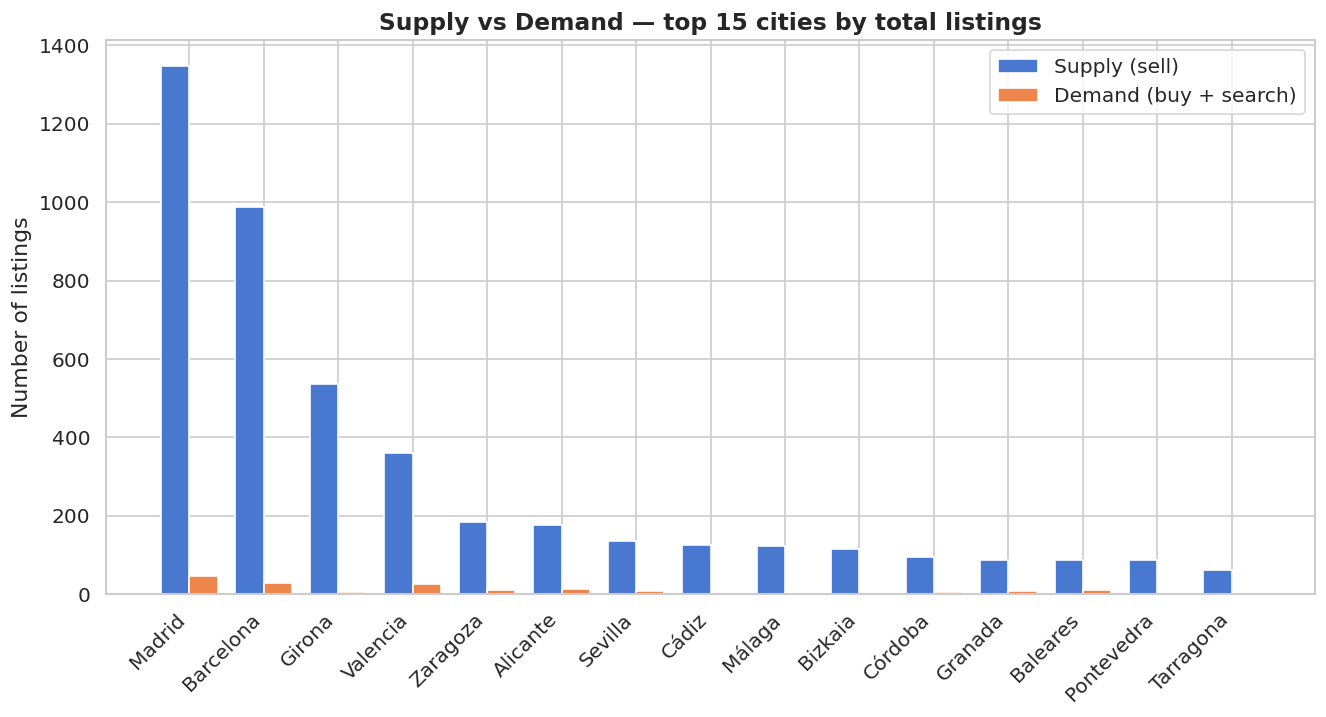

In [4]:
# ── 3a. Supply vs demand side by side — top cities ───────────────────────
top_cities = city_agg.nlargest(TOP_N, 'total')

x = np.arange(len(top_cities))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, top_cities['supply'], width=w, label='Supply (sell)',
       color=sns.color_palette('muted')[0])
ax.bar(x + w/2, top_cities['demand'], width=w, label='Demand (buy + search)',
       color=sns.color_palette('muted')[1])
ax.set_xticks(x)
ax.set_xticklabels(top_cities['city'], rotation=45, ha='right')
ax.set_title(f'Supply vs Demand — top {TOP_N} cities by total listings', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of listings')
ax.legend()
savefig('19_supply_vs_demand_by_city')

### Conclusiones Principales del Gráfico

Tabla resumen estructurada para validar y cuantificar las hipótesis del análisis de datos:

### Tabla Resumen de Hipótesis de Mercado (Sintetizadores)

| # | Hipótesis | Fenómeno Observado | Evidencia Visual / Indicador Clave | Implicación de Mercado |
| :--- | :--- | :--- | :--- | :--- |
| **1** | **Desequilibrio Estructural** | Exceso masivo de Oferta (*Supply*) frente a la Demanda (*Demand*) en todas las ubicaciones. | Dominio visual de las **barras azules** (oferta) sobre las de demanda en el gráfico general. | **Mercado de Compradores:** Hay mucho más stock disponible que compradores activos, lo que presiona los precios a la baja. |
| **2** | **Concentración de Liquidez** | El volumen de transacciones/anuncios se agrupa en pocas ciudades principales. | **Madrid y Barcelona** acumulan la mayor parte del volumen total; el resto forma una "cola larga" (*long tail*). | **Riesgo Geográfico:** La liquidez real solo existe en grandes núcleos. Las ciudades menores tienen un mercado muy delgado. |
| **3** | **Demanda "Invisible"** | En ciudades medias, la búsqueda de producto es casi inexistente o muy baja. | En ciudades como **Girona, Zaragoza o Cádiz**, la barra de demanda es apenas visible. | **Iliquidez y Fragmentación:** La demanda es esporádica. Vender en estas zonas implica tiempos de espera largos o necesidad de envío nacional. |
| **4** | **Ratio Oferta/Demanda Creciente** | El desequilibrio se agrava a medida que disminuye el tamaño de la ciudad. | El **ratio Oferta/Demanda** se vuelve más extremo en ciudades con menor volumen total. | **Dificultad de Venta:** En ciudades pequeñas, hay relativamente mucha menos demanda para la oferta disponible, aumentando el riesgo de no vender. |

### Siguientes pasos para la validación de datos:
Para cumplir con el objetivo de **"validar y cuantificar"**, tu análisis debería calcular:
1.  **Ratio Global S/D:** El promedio exacto de ofertas por cada demanda (ej. 5:1).
2.  **Índice de Herfindahl-Hirschman (HHI):** Para medir matemáticamente la concentración del mercado en Madrid/Barcelona vs. el resto.
3.  **Umbral de Visibilidad:** Definir a partir de qué valor numérico la demanda se considera "invisible" o estadísticamente irrelevante.
4.  **Correlación Volumen/Ratio:** Un gráfico de dispersión que confirme si a menor volumen de ciudad, mayor es el ratio de desequilibrio.

### Ratio Global Ponderado

- **Fórmula:** Suma Total Oferta / Suma Total Demanda
- **Significado:** "En todo el mercado, ¿cuántos anuncios hay por cada comprador real?"
- **Uso:** Este es el indicador real de presión de mercado.


In [5]:
# ✅ Opción Recomendada: Ratio Global Ponderado
total_supply = top_cities['supply'].sum()
total_demand = top_cities['demand'].sum()
global_ratio = total_supply / total_demand

print(f"Oferta Total: {total_supply}")
print(f"Demanda Total: {total_demand}")
print(f"Ratio Global S/D: {global_ratio:.2f}")
print(f"Interpretación: Hay {global_ratio:.1f} anuncios por cada comprador en el mercado.")

Oferta Total: 4511
Demanda Total: 174
Ratio Global S/D: 25.93
Interpretación: Hay 25.9 anuncios por cada comprador en el mercado.


### Indice de Herfindahl-Hirschman (HHI)


Métrica estándar para medir la concentración de mercado de forma matemática.

El HHI te dirá si el mercado está fragmentado (muchas ciudades compiten equilibradamente) o concentrado (Madrid y Barcelona dominan todo).

In [6]:
# Calcular acumulado porcentual
top_cities['total_listings'] = top_cities['supply'] + top_cities['demand']
top_cities = top_cities.sort_values('total_listings', ascending=False)
top_cities['cumulative_pct'] = top_cities['total_listings'].cumsum() / top_cities['total_listings'].sum() * 100

# Identificar cuántas ciudades cubren el 80% del mercado
top_cities_80 = top_cities[top_cities['cumulative_pct'] <= 80].shape[0]
print("Las ciudades concentran el 80% del volumen total del mercado.")
print(top_cities[['city', 'total_listings', 'cumulative_pct']])

Las ciudades concentran el 80% del volumen total del mercado.
          city  total_listings  cumulative_pct
30      Madrid            1393       29.733191
8    Barcelona            1015       51.398079
19      Girona             541       62.945571
44    Valencia             388       71.227321
47    Zaragoza             195       75.389541
2     Alicante             190       79.445037
39     Sevilla             145       82.540021
16       Cádiz             128       85.272145
32      Málaga             127       87.982924
9      Bizkaia             117       90.480256
17     Córdoba             101       92.636073
7     Baleares              98       94.727855
20     Granada              95       96.755603
36  Pontevedra              89       98.655283
41   Tarragona              63      100.000000


In [7]:
import numpy as np

# 1. Calcular la cuota de mercado de cada ciudad (en %)
top_cities['market_share'] = (top_cities['total_listings'] / top_cities['total_listings'].sum()) * 100

# 2. Calcular el cuadrado de cada cuota
top_cities['market_share_squared'] = top_cities['market_share'] ** 2

# 3. Sumar los cuadrados para obtener el HHI
hhi = top_cities['market_share_squared'].sum()

print(f"Índice HHI del Mercado: {hhi:.2f}")

Índice HHI del Mercado: 1638.31


### Interpretación del Resultado

El HHI oscila teóricamente entre 0 (competencia perfecta) y 10,000 (monopolio puro). Según los estándares económicos (DOJ/FTC):

| **Valor HHI** | **Tipo de Concentración**       | **Interpretación para tu Mercado**                                   |
|----------------|-------------------------------|---------------------------------------------------------------------------|
| < 1,500        | Mercado No Concentrado       | Muy fragmentado. Muchas ciudades compiten.                           |
| 1,500 -2,500   | Moderadamente Concentrado    | Hay líderes claros, pero hay competencia.                            |
| >2,500          | Altamente Concentrado        | Dominio de pocos jugadores.           |



In [8]:
# --- Análisis de Concentración Top 2 ---

# 1. Identificar Madrid y Barcelona (Asegúrate de tener los nombres correctos)
top_2 = top_cities[top_cities['city'].isin(['Madrid', 'Barcelona'])]
rest = top_cities[~top_cities['city'].isin(['Madrid', 'Barcelona'])]

# 2. Calcular su cuota conjunta
share_top_2 = top_2['market_share'].sum()
share_rest = rest['market_share'].sum()

# 3. Calcular el HHI contribuido solo por Madrid y Barcelona
hhi_top_2 = top_2['market_share_squared'].sum()
hhi_rest = rest['market_share_squared'].sum()

print(f"--- Concentración de Mercado ---")
print(f"Cuota Madrid + Barcelona: {share_top_2:.2f}%")
print(f"Cuota Resto de ciudades: {share_rest:.2f}%")
print(f"\nHHI Total: {hhi:.2f}")
print(f"  -> Contribución Top 2 (Mad/Bcn): {hhi_top_2:.2f} ({(hhi_top_2/hhi)*100:.1f}% del HHI total)")
print(f"  -> Contribución Resto: {hhi_rest:.2f} ({(hhi_rest/hhi)*100:.1f}% del HHI total)")

--- Concentración de Mercado ---
Cuota Madrid + Barcelona: 51.40%
Cuota Resto de ciudades: 48.60%

HHI Total: 1638.31
  -> Contribución Top 2 (Mad/Bcn): 1353.43 (82.6% del HHI total)
  -> Contribución Resto: 284.88 (17.4% del HHI total)


Dado que el HHI usa cuadrados, los jugadores grandes pesan desproporcionadamente más. Es muy probable que descubras que solo Madrid y Barcelona aportan más del 50-60% del valor total del HHI, demostrando matemáticamente que el mercado gira en torno a ellas.

### 4. Visualización del HHI (Gráfico de Contribución)

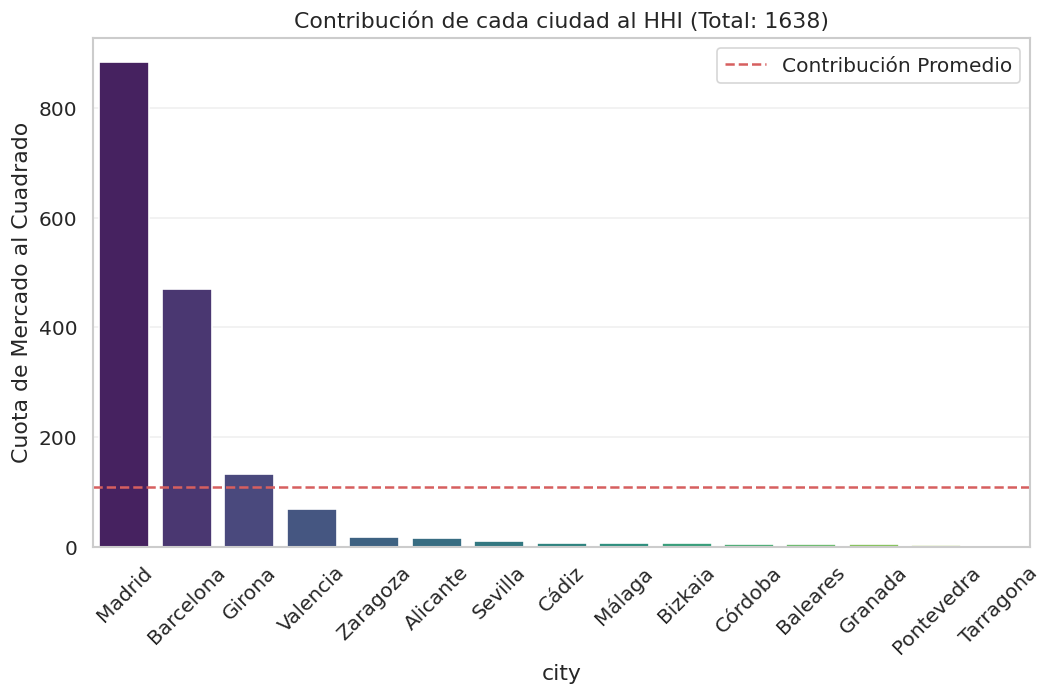

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# Gráfico de barras de la contribución al HHI por ciudad
sns.barplot(data=top_cities.sort_values('market_share_squared', ascending=False), 
            x='city', y='market_share_squared', hue='city',palette='viridis')

plt.axhline(y=hhi/len(top_cities), color='r', linestyle='--', label='Contribución Promedio')
plt.title(f'Contribución de cada ciudad al HHI (Total: {hhi:.0f})')
plt.ylabel('Cuota de Mercado al Cuadrado')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El Índice de Herfindahl-Hirschman (HHI) calculado es de 1638.31, lo que clasifica el mercado como Moderadamente Concentrado.

Matemáticamente, Madrid y Barcelona representan el 82.6% de la cuota de mercado total, pero contribuyen con el 51.40% de la concentración total del índice. 

Esto confirma que cualquier estrategia de mercado debe priorizar estas dos lugares, y tener al resto del territorio como un mercado secundario fragmentado.

### Umbral de Visibilidad:

métrica que define el "punto de corte" para decidir en qué ciudades vale la pena invertir recursos y cuáles son demasiado pequeñas para ser relevantes.
Complementa perfectamente al HHI y Pareto. Mientras HHI te dice qué tan concentrado está el mercado, el Umbral de Visibilidad te dice dónde poner el límite para tu estrategia.

In [10]:
# --- 1. Umbral por Cuota de Mercado (%) ---
# Una ciudad es "visible" si tiene al menos X% del mercado total
visibility_threshold_pct = 2.0  # Ejemplo: 2% del mercado total
top_cities['visible_by_share'] = top_cities['market_share'] >= visibility_threshold_pct

# --- 2. Umbral por Volumen Absoluto ---
# Una ciudad es "visible" si tiene al menos X anuncios totales
visibility_threshold_volume = 100  # Ejemplo: mínimo 100 listings
top_cities['visible_by_volume'] = top_cities['total_listings'] >= visibility_threshold_volume

# --- 3. Umbral por Demanda Mínima ---
# Una ciudad es "visible" si tiene al menos X demandas (liquidez real)
visibility_threshold_demand = 10  # Ejemplo: mínimo 10 compradores activos
top_cities['visible_by_demand'] = top_cities['demand'] >= visibility_threshold_demand

# --- 4. Visibilidad Compuesta (Todas las condiciones) ---
top_cities['fully_visible'] = (
    top_cities['visible_by_share'] & 
    top_cities['visible_by_volume'] & 
    top_cities['visible_by_demand']
)

# --- Resumen ---
print(f"=== Umbral de Visibilidad ===")
print(f"Ciudades visibles por cuota (>2%): {top_cities['visible_by_share'].sum()}")
print(f"Ciudades visibles por volumen (>100 listings): {top_cities['visible_by_volume'].sum()}")
print(f"Ciudades visibles por demanda (>10 buyers): {top_cities['visible_by_demand'].sum()}")
print(f"Ciudades FULLY VISIBLES (cumplen todo): {top_cities['fully_visible'].sum()}")

=== Umbral de Visibilidad ===
Ciudades visibles por cuota (>2%): 13
Ciudades visibles por volumen (>100 listings): 11
Ciudades visibles por demanda (>10 buyers): 6
Ciudades FULLY VISIBLES (cumplen todo): 5


### Tabla de Clasificación de Ciudades

- Esto te permite ver claramente qué ciudades pasan el filtro:

In [11]:
# Mostrar tabla de visibilidad
print(top_cities[['city', 'total_listings', 'market_share', 'demand', 'fully_visible']].to_string(index=False))

      city  total_listings  market_share  demand  fully_visible
    Madrid            1393     29.733191      47           True
 Barcelona            1015     21.664888      28           True
    Girona             541     11.547492       6          False
  Valencia             388      8.281750      27           True
  Zaragoza             195      4.162220      11           True
  Alicante             190      4.055496      13           True
   Sevilla             145      3.094984       8          False
     Cádiz             128      2.732124       3          False
    Málaga             127      2.710779       4          False
   Bizkaia             117      2.497332       1          False
   Córdoba             101      2.155816       6          False
  Baleares              98      2.091782      10          False
   Granada              95      2.027748       8          False
Pontevedra              89      1.899680       1          False
 Tarragona              63      1.344717


### Resumen:

1. **Cuota de Mercado > 2% (Market Share):**
   - Es el nivel de relevancia relativa de una ciudad dentro del mercado nacional.
   - Si hay ~15 ciudades en el dataset, cada una tendría un 6.67% si el mercado fuera perfectamente simétrico.
   - Fijar el umbral en un 2% es un criterio estratégico no matemático que equilibra eliminar "ruido" sin excluir mercados medianos viables.
   - Ciudades con menos del 2% son estadísticamente irrelevantes para una estrategia macro, ya que su impacto en el volumen total es mínimo.
   - Madrid (\~29%) y Barcelona (\~21%) superan ampliamente el umbral.
   - Tarragona (~2%) está justo en el límite.
   - Ciudades menores (<1%) se descartan para estrategias prioritarias.
   - **Ajuste:** 
     - Más estricto (>5%): Solo operarías en Madrid, Barcelona y quizás Girona. (Máxima concentración).
     - Más laxo (>1%): Incluirías casi todas las ciudades de tu lista. (Expansión agresiva).


2. **Volumen Total > 100 (Total Listings):**
   - Mide la liquidez absoluta y la significancia estadística.
   - Con menos de 100 anuncios al año, los cálculos de precios medios o tendencias son muy volátiles y poco fiables.
   - Un solo anuncio caro puede influir artificialmente en la media.
   - Gestionar una ciudad con 20 anuncios al mes no justifica un equipo o campaña dedicada; el coste fijo de operar podría superar los beneficios.
   - Frecuencia: 100 anuncios al año son ~8-9 por semana, lo mínimo para tener "actividad constante" visible.
   - **Ajuste:** 
     - Producto de alto valor (ej. Inmobiliario): Podrías bajar a 50.
     - Producto rotativo (ej. Coches/Móviles): Deberías subir a 500+.

3. **Demanda > 10 (Demand):**
   - Mide la salud real del mercado.
   - Es el filtro más importante para evitar "mercados fantasma".
   - Puedes tener 500 anuncios (Oferta), pero si solo hay 2 compradores (Demanda), el mercado está estancado. Es una "trampa de liquidez".
   - 10 demandas aseguran un flujo mínimo de compradores reales.
   - **Ajuste:** 
     - Mercado lento: Déjalo en 5-10.
     - Mercado rápido: Súbelo a 20-50 para asegurar rotación rápida.

<br>


**Conclusión:**  
Esto representa el 67.88% del mercado total, lo que confirma que los recursos deben concentrarse en un núcleo reducido de ciudades prioritarias, mientras el resto se gestiona de forma oportunista.

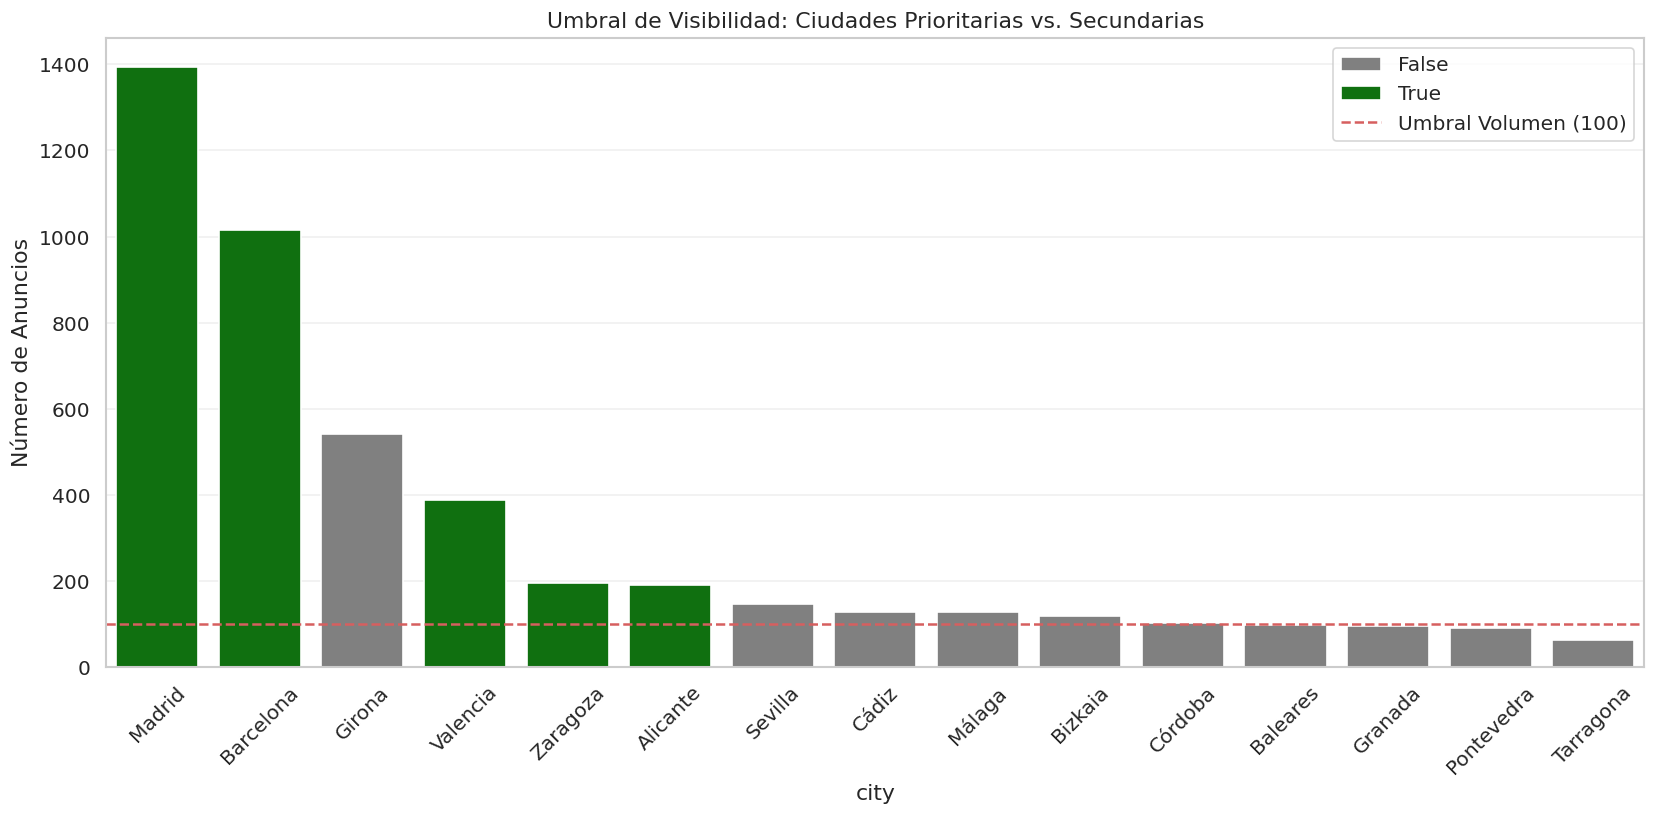

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Gráfico de barras con color según visibilidad
sns.barplot(data=top_cities, 
            x='city', 
            y='total_listings', 
            hue='fully_visible', 
            palette={True: 'green', False: 'gray'},
            legend=True)

plt.axhline(y=visibility_threshold_volume, color='r', linestyle='--', 
            label=f'Umbral Volumen ({visibility_threshold_volume})')
plt.title('Umbral de Visibilidad: Ciudades Prioritarias vs. Secundarias')
plt.ylabel('Número de Anuncios')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El Umbral de Visibilidad identifica que solo 5 ciudades de las 15 analizadas cumplen los criterios mínimos para una estrategia dedicada.

### Interpretación:

- Mercado Visible (Prioritario): ~68% del volumen total está en estas 5 ciudades. Aquí es donde debes enfocar el 80% de tus recursos.

- Mercado No Visible (Secundario): ~32% del volumen está disperso en el resto de ciudades. Se gestiona de forma pasiva o automatizada.

In [13]:
# Market classification using sd_ratio (%) already computed in city_agg
# Thresholds: >10% = High Demand, 5-10% = Balanced, <5% = Buyer Market (Oversupply)
def market_type(ratio):
    if ratio > 10:  return 'High Demand'
    elif ratio > 5: return 'Balanced'
    else:           return 'Buyer Market (Oversupply)'

top_cities['market_status'] = top_cities['sd_ratio'].apply(market_type)

print(top_cities[['city', 'supply', 'demand', 'sd_ratio', 'market_status']]
      .sort_values('sd_ratio', ascending=False).to_string(index=False))

      city  supply  demand  sd_ratio             market_status
  Baleares      88      10 11.363636               High Demand
   Granada      87       8  9.195402                  Balanced
  Valencia     361      27  7.479224                  Balanced
  Alicante     177      13  7.344633                  Balanced
   Córdoba      95       6  6.315789                  Balanced
  Zaragoza     184      11  5.978261                  Balanced
   Sevilla     137       8  5.839416                  Balanced
    Madrid    1346      47  3.491828 Buyer Market (Oversupply)
    Málaga     123       4  3.252033 Buyer Market (Oversupply)
 Barcelona     987      28  2.836879 Buyer Market (Oversupply)
     Cádiz     125       3  2.400000 Buyer Market (Oversupply)
 Tarragona      62       1  1.612903 Buyer Market (Oversupply)
Pontevedra      88       1  1.136364 Buyer Market (Oversupply)
    Girona     535       6  1.121495 Buyer Market (Oversupply)
   Bizkaia     116       1  0.862069 Buyer Market (Over

In [14]:
top_cities[['city','market_status']]

,city,market_status
30,Madrid,Buyer Market (Oversupply)
8,Barcelona,Buyer Market (Oversupply)
19,Girona,Buyer Market (Oversupply)
44,Valencia,Balanced
47,Zaragoza,Balanced
2,Alicante,Balanced
39,Sevilla,Balanced
16,Cádiz,Buyer Market (Oversupply)
32,Málaga,Buyer Market (Oversupply)
9,Bizkaia,Buyer Market (Oversupply)


B. Visualización del Desequilibrio (Gráfico de Barras Apiladas o Ratio)

In [15]:
top_cities.columns

Index(['city', 'supply', 'demand', 'total', 'med_price', 'mean_seen',
       'sd_ratio', 'total_listings', 'cumulative_pct', 'market_share',
       'market_share_squared', 'visible_by_share', 'visible_by_volume',
       'visible_by_demand', 'fully_visible', 'market_status'],
      dtype='object')

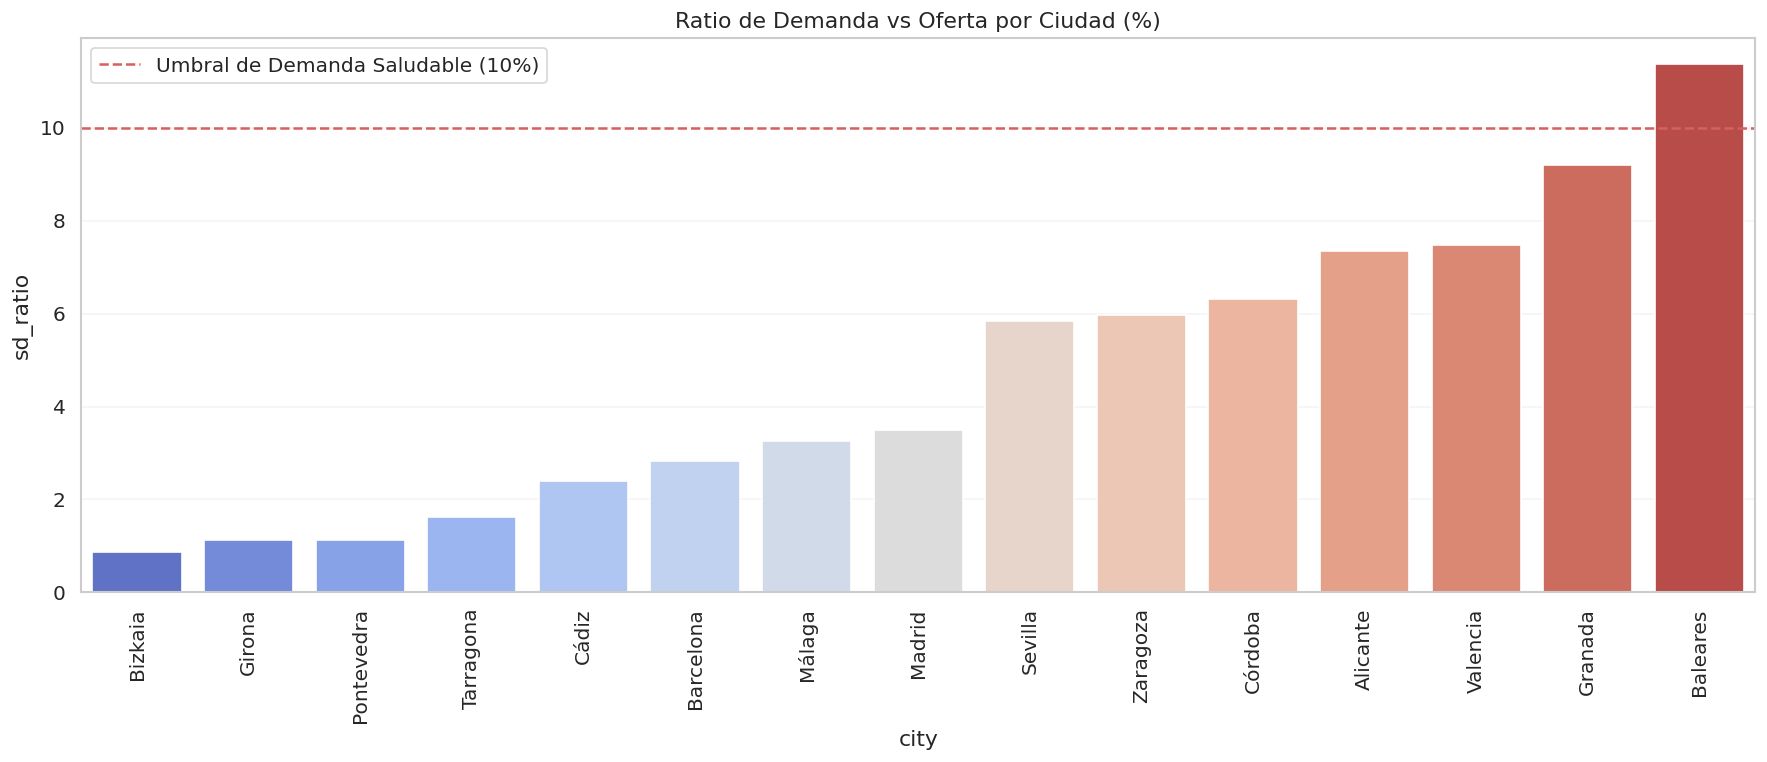

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))

sns.barplot(data=top_cities.sort_values('sd_ratio'),
            x='city', y='sd_ratio', hue='city', palette='coolwarm')

plt.axhline(y=10, color='r', linestyle='--', label='Umbral de Demanda Saludable (10%)')
plt.title('Ratio de Demanda vs Oferta por Ciudad (%)')
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

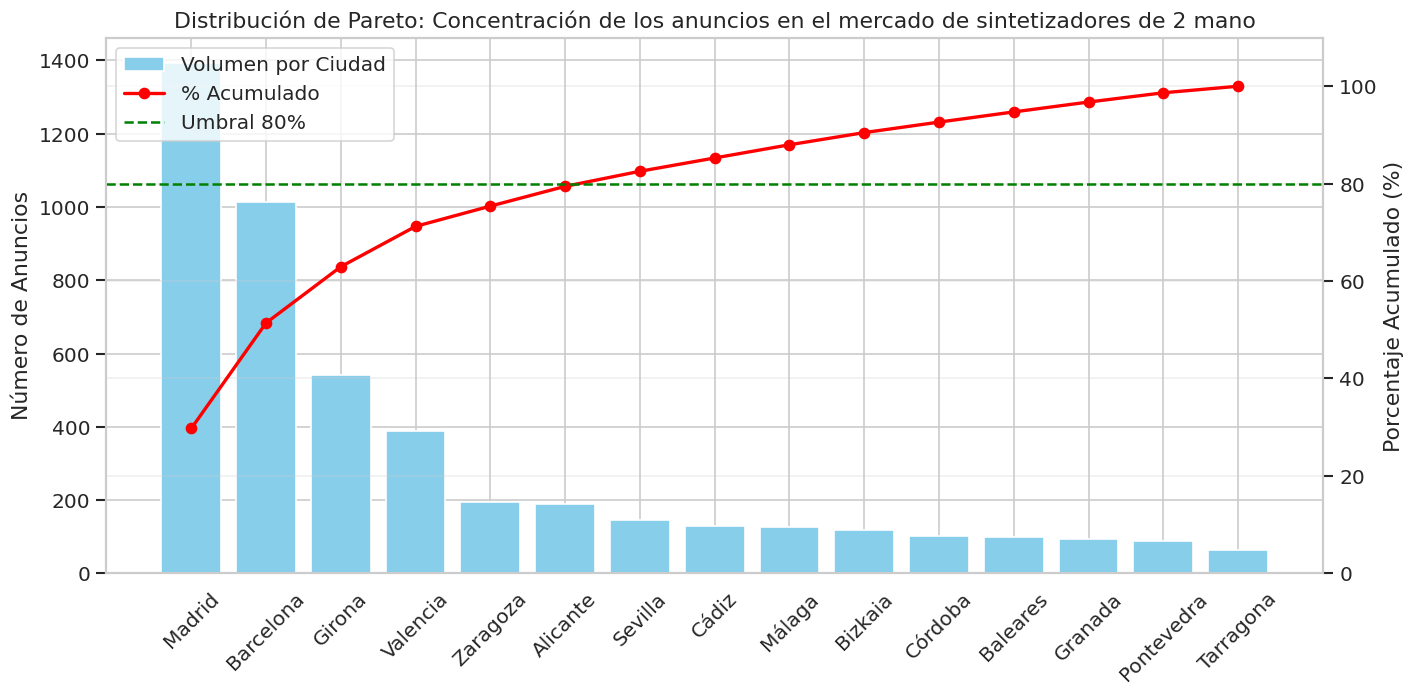

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras de volumen por ciudad
ax1.bar(top_cities['city'], top_cities['total_listings'], color='skyblue', label='Volumen por Ciudad')
ax1.set_ylabel('Número de Anuncios')
ax1.set_title('Distribución de Pareto: Concentración de los anuncios en el mercado de sintetizadores de 2 mano')
ax1.tick_params(axis='x', rotation=45)

# Línea de porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(top_cities['city'], top_cities['cumulative_pct'], color='red', marker='o', linewidth=2, label='% Acumulado')
ax2.axhline(y=80, color='green', linestyle='--', label='Umbral 80%')
ax2.set_ylabel('Porcentaje Acumulado (%)')
ax2.set_ylim(0, 110)

# Unir leyendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import numpy as np

# =============================================================================
# 1. NORMALIZAR MÉTRICAS (0-100)
# =============================================================================

def normalize_volume(x, max_val):
    """Volume: more is better"""
    return min((x / max_val) * 100, 100)

def normalize_hhi_contrib(x, max_val):
    """HHI contribution: more is better (weight in market)"""
    return min((x / max_val) * 100, 100)

def normalize_demand_ratio(x, max_val):
    """D/S ratio (%): more demand relative to supply is better"""
    return min((x / max_val) * 100, 100)

def normalize_visibility(x):
    """Visibility: binary"""
    return 100 if x else 0

# =============================================================================
# 2. CALCULAR SCORES INDIVIDUALES
# =============================================================================

max_volume      = top_cities['total_listings'].max()
max_hhi         = top_cities['market_share_squared'].max()
max_demand_ratio = top_cities['sd_ratio'].max()

top_cities['score_volume']     = top_cities['total_listings'].apply(lambda x: normalize_volume(x, max_volume))
top_cities['score_hhi']        = top_cities['market_share_squared'].apply(lambda x: normalize_hhi_contrib(x, max_hhi))
top_cities['score_demand']     = top_cities['sd_ratio'].apply(lambda x: normalize_demand_ratio(x, max_demand_ratio))
top_cities['score_visibility'] = top_cities['fully_visible'].apply(normalize_visibility)

# =============================================================================
# 3. SCORE FINAL PONDERADO
# Note: stability removed — it was the inverse of demand ratio (same data, double-counted)
# =============================================================================

weights = {
    'volume':     0.35,   # 35% — market size
    'hhi':        0.25,   # 25% — market share weight
    'demand':     0.30,   # 30% — relative demand (D/S ratio %)
    'visibility': 0.10,   # 10% — meets minimum thresholds
}

top_cities['final_score'] = (
    top_cities['score_volume']     * weights['volume'] +
    top_cities['score_hhi']        * weights['hhi'] +
    top_cities['score_demand']     * weights['demand'] +
    top_cities['score_visibility'] * weights['visibility']
)

# =============================================================================
# 4. CLASIFICACIÓN POR PRIORIDAD
# =============================================================================

def priority_level(score):
    if score >= 80: return 'ALTA'
    elif score >= 50: return 'MEDIA'
    else: return 'BAJA'

top_cities['priority'] = top_cities['final_score'].apply(priority_level)

# =============================================================================
# 5. TABLA MAESTRA
# =============================================================================

master_table = top_cities[[
    'city', 'total_listings', 'market_share', 'sd_ratio',
    'market_status', 'fully_visible', 'final_score', 'priority'
]].copy().rename(columns={
    'total_listings': 'Volumen',
    'market_share':   'Cuota (%)',
    'sd_ratio':       'D/S Ratio (%)',
    'market_status':  'Mercado',
    'fully_visible':  'Visible',
    'final_score':    'SCORE',
    'priority':       'PRIORIDAD'
}).sort_values('SCORE', ascending=False)

master_table['Cuota (%)']    = master_table['Cuota (%)'].round(2)
master_table['D/S Ratio (%)'] = master_table['D/S Ratio (%)'].round(2)
master_table['SCORE']        = master_table['SCORE'].round(1)

print("=" * 80)
print(" TABLA MAESTRA DE CONCENTRACIÓN DE MERCADO")
print("=" * 80)
print(master_table.to_string(index=False))
print("=" * 80)

 TABLA MAESTRA DE CONCENTRACIÓN DE MERCADO
      city  Volumen  Cuota (%)  D/S Ratio (%)                   Mercado  Visible  SCORE PRIORIDAD
    Madrid     1393      29.73           3.49 Buyer Market (Oversupply)     True   79.2     MEDIA
 Barcelona     1015      21.66           2.84 Buyer Market (Oversupply)     True   56.3     MEDIA
  Valencia      388       8.28           7.48                  Balanced     True   41.4      BAJA
  Alicante      190       4.06           7.34                  Balanced     True   34.6      BAJA
  Baleares       98       2.09          11.36               High Demand    False   32.6      BAJA
  Zaragoza      195       4.16           5.98                  Balanced     True   31.2      BAJA
   Granada       95       2.03           9.20                  Balanced    False   26.8      BAJA
    Girona      541      11.55           1.12 Buyer Market (Oversupply)    False   20.3      BAJA
   Córdoba      101       2.16           6.32                  Balanced    

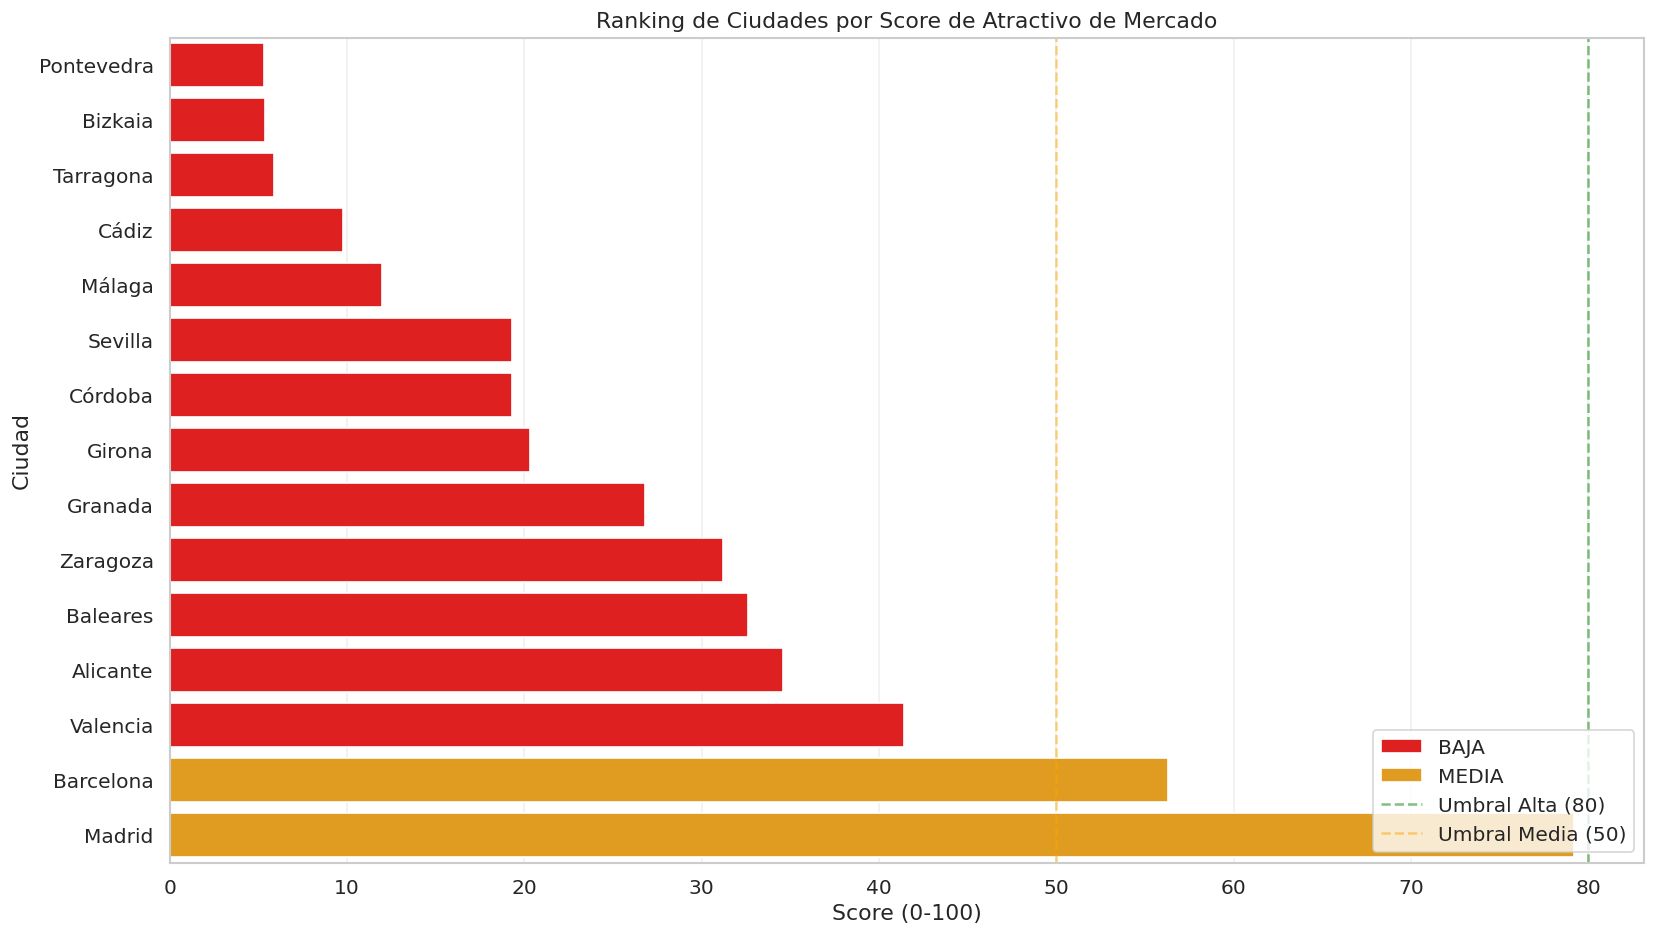

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

palette = {'ALTA': 'green', 'MEDIA': 'orange', 'BAJA': 'red'}

sns.barplot(data=master_table.sort_values('SCORE', ascending=True),
            x='SCORE',
            y='city',
            hue='PRIORIDAD',
            palette=palette,
            legend=True)

plt.axvline(x=80, color='green', linestyle='--', alpha=0.5, label='Umbral Alta (80)')
plt.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='Umbral Media (50)')
plt.title('Ranking de Ciudades por Score de Atractivo de Mercado')
plt.xlabel('Score (0-100)')
plt.ylabel('Ciudad')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
!pwd

/home/ion/dev/github/hispasonic/notebooks


## 4. Supply/demand ratio per city — ranking and price correlation

Saved → ../reports/figures/20_sd_ratio_ranking_by_city.png


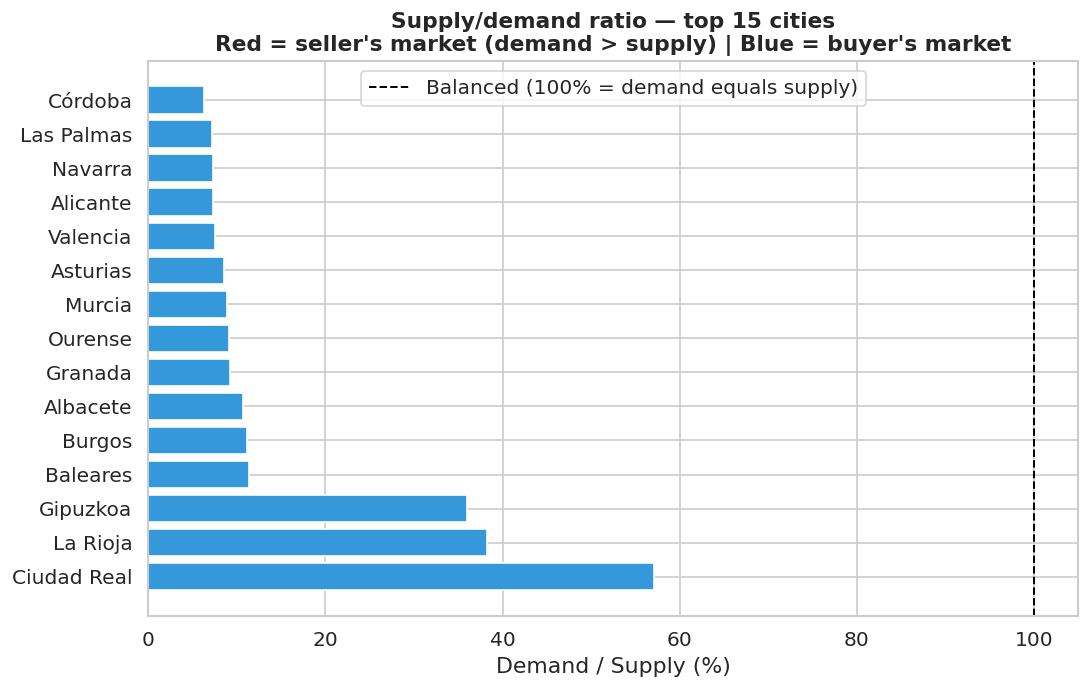

In [21]:
# ── 4a. S/D ratio ranking ────────────────────────────────────────────────
ratio_ranked = city_agg.dropna(subset=['sd_ratio']).nlargest(TOP_N, 'sd_ratio')

fig, ax = plt.subplots(figsize=(10, 6))
# 100% = demand equals supply (balanced market); above = seller's market
colors = ['#e74c3c' if r > 100 else '#3498db' for r in ratio_ranked['sd_ratio']]
bars = ax.barh(ratio_ranked['city'], ratio_ranked['sd_ratio'], color=colors)
ax.axvline(100, color='black', linestyle='--', linewidth=1.2, label='Balanced (100% = demand equals supply)')
ax.set_title(f'Supply/demand ratio — top {TOP_N} cities\n'
             "Red = seller's market (demand > supply) | Blue = buyer's market",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Demand / Supply (%)')
ax.set_ylabel('')
ax.legend()
savefig('20_sd_ratio_ranking_by_city')

Saved → ../reports/figures/21_sd_ratio_vs_price_scatter.png


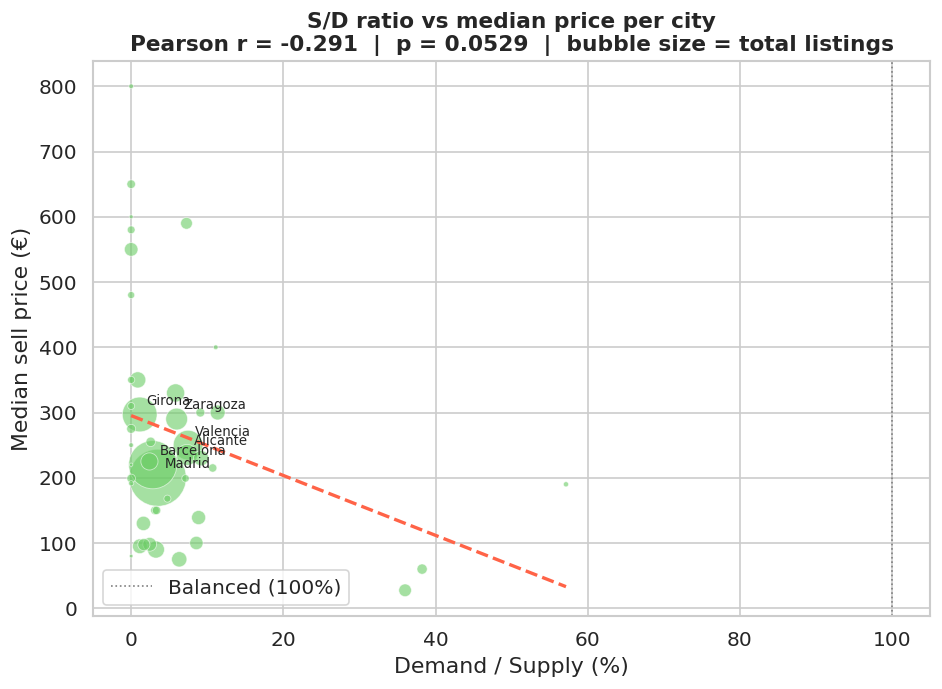

In [22]:
# ── 4b. S/D ratio vs median price — scatter with regression ──────────────
plot_df = city_agg.dropna(subset=['sd_ratio', 'med_price'])
plot_df = plot_df[plot_df['med_price'] > 0]

# Pearson correlation
r, p = stats.pearsonr(plot_df['sd_ratio'], plot_df['med_price'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_df['sd_ratio'], plot_df['med_price'],
           s=plot_df['total'] * 0.8, alpha=0.6,
           color=sns.color_palette('muted')[2], edgecolors='white', linewidth=0.5)

# Regression line
m, b = np.polyfit(plot_df['sd_ratio'], plot_df['med_price'], 1)
x_line = np.linspace(plot_df['sd_ratio'].min(), plot_df['sd_ratio'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, linestyle='--')

# Label top cities
for _, row in plot_df.nlargest(6, 'total').iterrows():
    ax.annotate(row['city'], (row['sd_ratio'], row['med_price']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.axvline(100, color='grey', linestyle=':', linewidth=1, label='Balanced (100%)')
ax.set_title(f'S/D ratio vs median price per city\n'
             f'Pearson r = {r:.3f}  |  p = {p:.4f}  |  bubble size = total listings',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Demand / Supply (%)')
ax.set_ylabel('Median sell price (€)')
ax.legend()
savefig('21_sd_ratio_vs_price_scatter')

Saved → ../reports/figures/22_sd_ratio_and_price_dual_axis.png


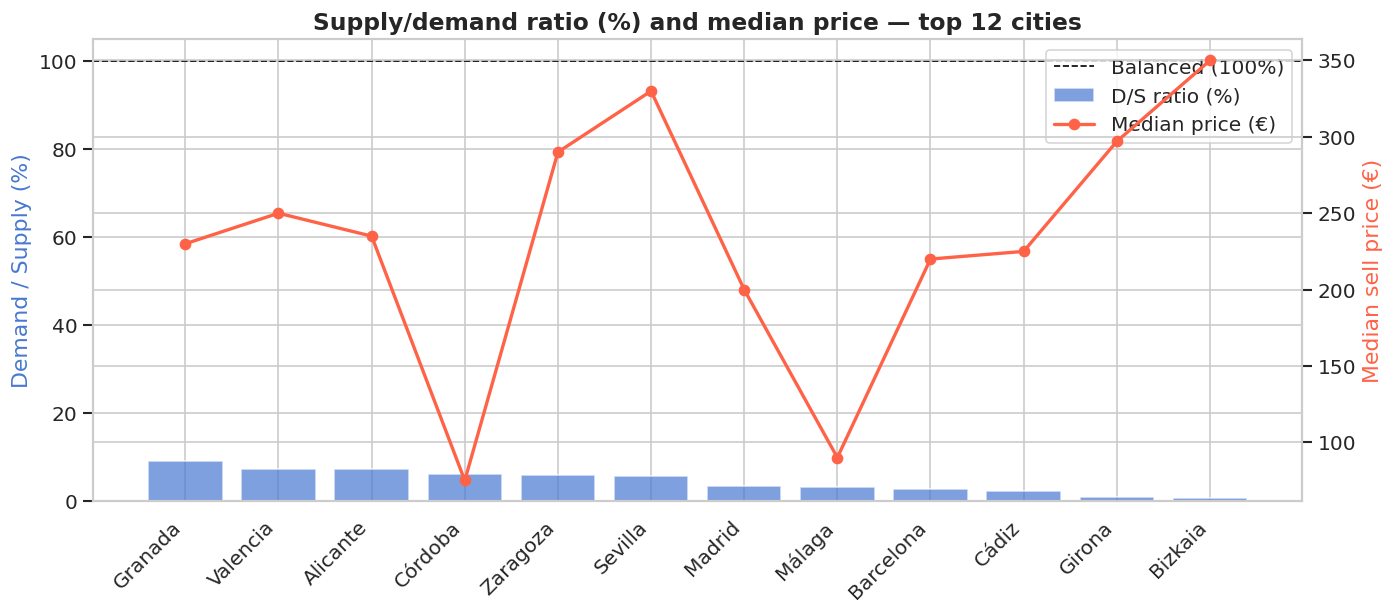

In [23]:
# ── 4c. Dual axis: ratio and price by city ────────────────────────────────
dual_df = city_agg.dropna(subset=['sd_ratio', 'med_price']).nlargest(12, 'total').sort_values('sd_ratio', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

x = np.arange(len(dual_df))
ax1.bar(x, dual_df['sd_ratio'], color=sns.color_palette('muted')[0], alpha=0.7, label='D/S ratio (%)')
ax2.plot(x, dual_df['med_price'], color='tomato', marker='o', linewidth=2, label='Median price (€)')

# Reference line: 100% = balanced market (demand equals supply)
ax1.axhline(100, color='black', linestyle='--', linewidth=1, label='Balanced (100%)')
ax1.set_xticks(x)
ax1.set_xticklabels(dual_df['city'], rotation=45, ha='right')
ax1.set_ylabel('Demand / Supply (%)', color=sns.color_palette('muted')[0])
ax2.set_ylabel('Median sell price (€)', color='tomato')
ax1.set_title('Supply/demand ratio (%) and median price — top 12 cities', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
savefig('22_sd_ratio_and_price_dual_axis')

## 5. Temporal evolution of supply, demand and ratio per city

In [24]:
# Aggregate by city + scrape date
time_city = df.groupby(['city', 'date_scrapped']).agg(
    supply    = ('is_supply', 'sum'),
    demand    = ('is_demand', 'sum'),
    med_price = ('price', 'median')
).reset_index()

# Express as percentage, consistent with city_agg sd_ratio
time_city['sd_ratio'] = (time_city['demand'] / time_city['supply'].replace(0, np.nan)) * 100

# Pick top 5 cities by total listings for temporal charts
top5_cities = city_agg.nlargest(5, 'total')['city'].tolist()
print('Top 5 cities for temporal analysis:', top5_cities)

Top 5 cities for temporal analysis: ['Madrid', 'Barcelona', 'Girona', 'Valencia', 'Zaragoza']


Saved → ../reports/figures/23_supply_demand_over_time_by_city.png


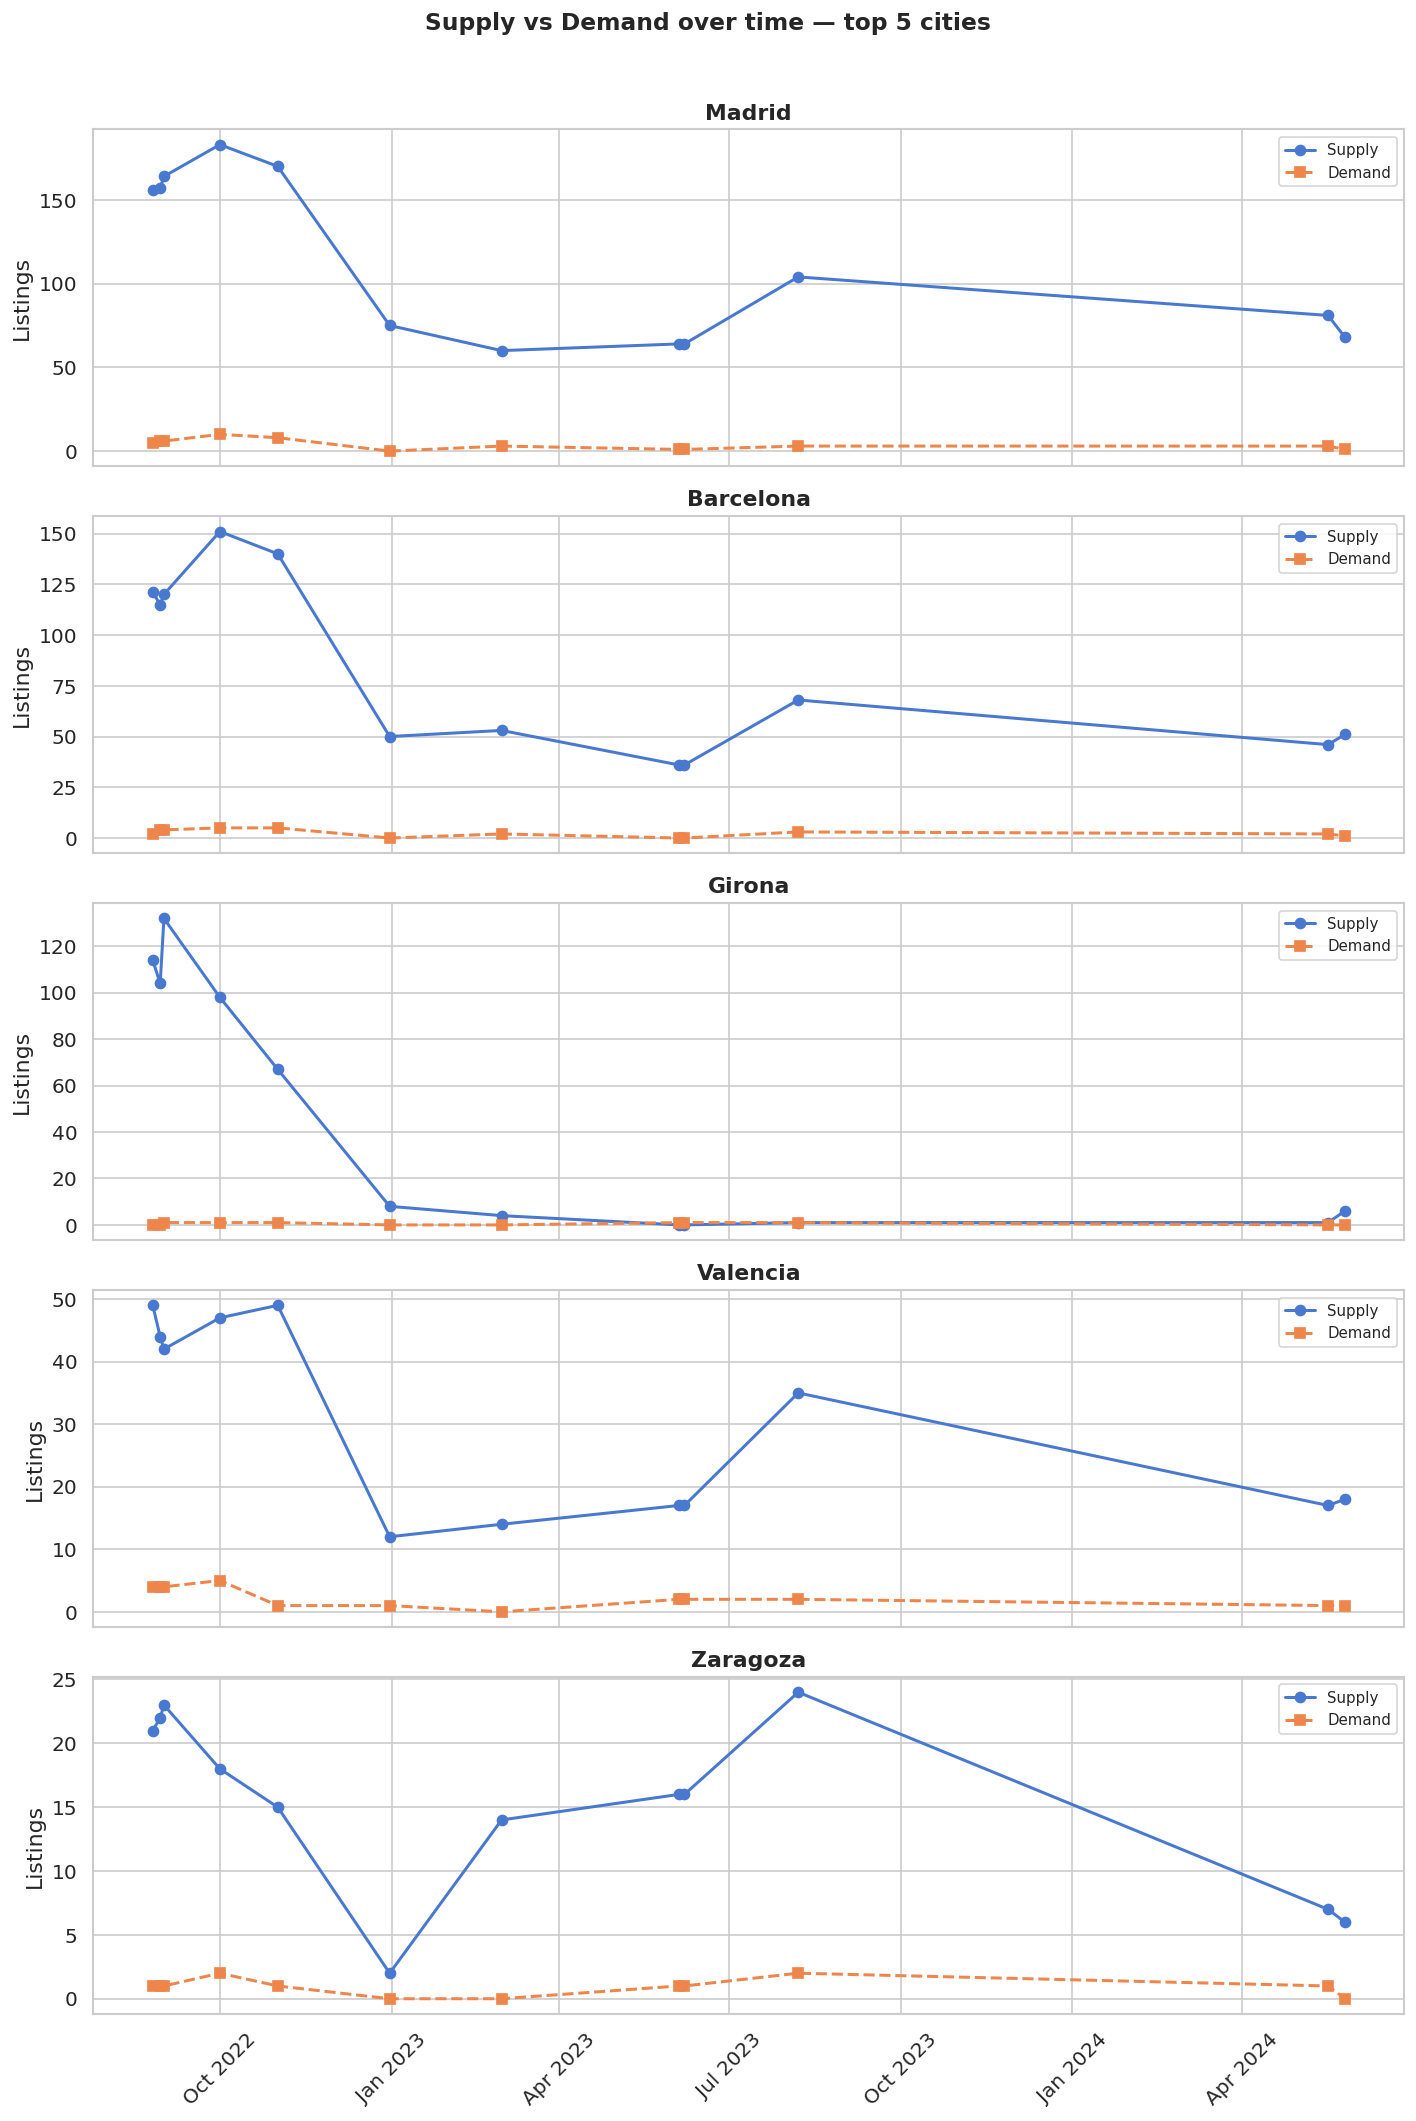

In [25]:
# ── 5a. Supply and demand over time per city ──────────────────────────────
fig, axes = plt.subplots(len(top5_cities), 1, figsize=(12, 3.5 * len(top5_cities)), sharex=True)

for ax, city in zip(axes, top5_cities):
    sub = time_city[time_city['city'] == city].sort_values('date_scrapped')
    ax.plot(sub['date_scrapped'], sub['supply'], marker='o', label='Supply',
            color=sns.color_palette('muted')[0], linewidth=1.8)
    ax.plot(sub['date_scrapped'], sub['demand'], marker='s', label='Demand',
            color=sns.color_palette('muted')[1], linewidth=1.8, linestyle='--')
    ax.set_title(city, fontweight='bold')
    ax.set_ylabel('Listings')
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
fig.suptitle('Supply vs Demand over time — top 5 cities', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('23_supply_demand_over_time_by_city')

Saved → ../reports/figures/24_sd_ratio_evolution_by_city.png


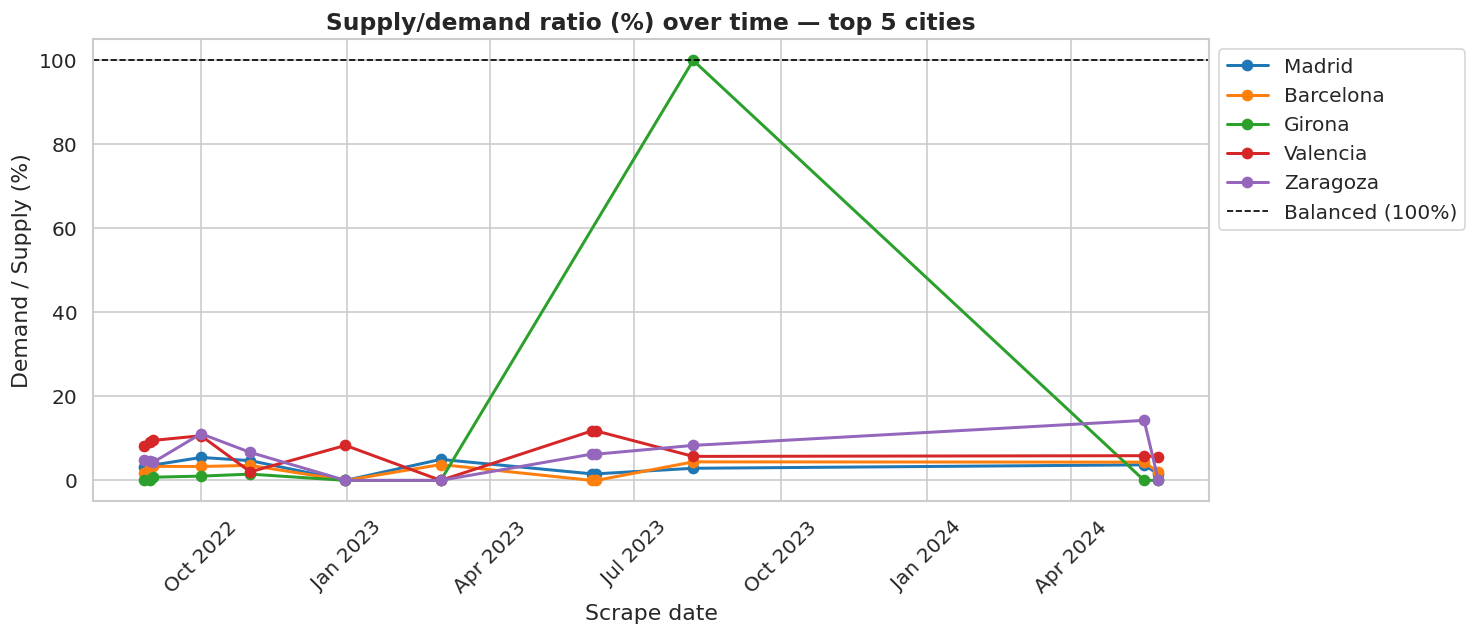

In [26]:
# ── 5b. S/D ratio evolution over time per city ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', n_colors=len(top5_cities))

for i, city in enumerate(top5_cities):
    sub = time_city[time_city['city'] == city].sort_values('date_scrapped').dropna(subset=['sd_ratio'])
    ax.plot(sub['date_scrapped'], sub['sd_ratio'], marker='o',
            label=city, color=palette[i], linewidth=1.8)

# 100% = balanced market; all cities are well below this line (buyer's market)
ax.axhline(100, color='black', linestyle='--', linewidth=1, label='Balanced (100%)')
ax.set_title('Supply/demand ratio (%) over time — top 5 cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Demand / Supply (%)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('24_sd_ratio_evolution_by_city')

In [27]:
# ── 5c. Does the ratio predict next-period price? (lagged correlation) ────
# For each city, correlate sd_ratio(t) with med_price(t+1)
lag_results = []

for city in city_agg['city']:
    sub = (time_city[time_city['city'] == city]
           .sort_values('date_scrapped')
           .dropna(subset=['sd_ratio', 'med_price']))
    if len(sub) < 4:
        continue
    ratio_t  = sub['sd_ratio'].values[:-1]
    price_t1 = sub['med_price'].values[1:]
    if len(ratio_t) < 3:
        continue
    # Skip cities where ratio or price is constant (no variance → NaN correlation)
    if np.std(ratio_t) == 0 or np.std(price_t1) == 0:
        continue
    r_lag, p_lag = stats.pearsonr(ratio_t, price_t1)
    lag_results.append({'city': city, 'lag_r': r_lag, 'lag_p': p_lag, 'n': len(ratio_t)})

lag_df = pd.DataFrame(lag_results).sort_values('lag_r', ascending=False)

# Mark statistical significance
lag_df['significant'] = lag_df['lag_p'] < 0.05

print('Cities where S/D ratio (t) correlates with price (t+1):')
print(lag_df.to_string(index=False))

Cities where S/D ratio (t) correlates with price (t+1):
       city     lag_r    lag_p  n  significant
   Valencia  0.819291 0.002030 11         True
   Albacete  0.508531 0.133375 10        False
   Zaragoza  0.504783 0.113284 11        False
     Málaga  0.423383 0.194448 11        False
   Baleares  0.302795 0.365421 11        False
       León  0.296779 0.438043  9        False
   Alicante  0.199914 0.555618 11        False
  Barcelona  0.118231 0.729176 11        False
     Madrid  0.035100 0.918398 11        False
   Asturias -0.007915 0.981573 11        False
     Girona -0.044492 0.909510  9        False
    Navarra -0.134427 0.693535 11        False
 Pontevedra -0.160958 0.636364 11        False
   La Rioja -0.167489 0.751116  6        False
     Murcia -0.185081 0.585877 11        False
  Cantabria -0.196205 0.563125 11        False
    Ourense -0.210245 0.559886 10        False
    Granada -0.228432 0.499296 11        False
    Sevilla -0.249337 0.459676 11        False
  Ta

Saved → ../reports/figures/27_lagged_correlation_sd_ratio_vs_price.png


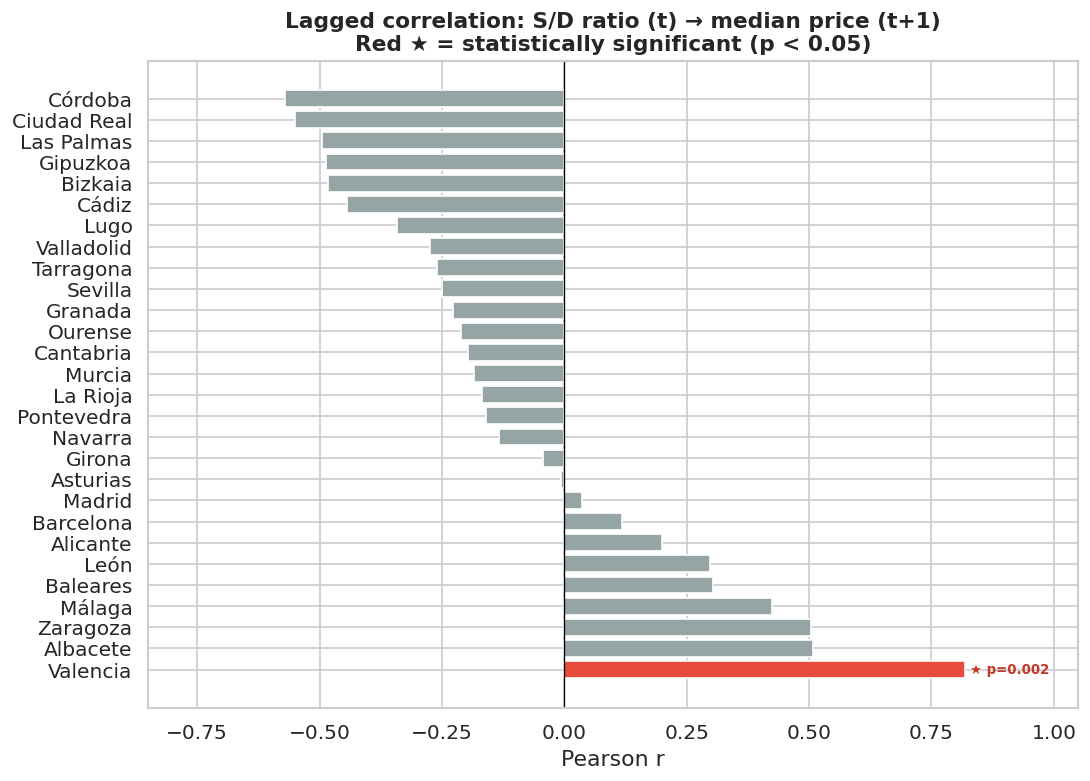

In [28]:
# ── 5d. Lagged correlation — visual ranking ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if sig else '#95a5a6' for sig in lag_df['significant']]
bars = ax.barh(lag_df['city'], lag_df['lag_r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

# Significance markers
for i, (_, row) in enumerate(lag_df.iterrows()):
    if row['significant']:
        ax.text(row['lag_r'] + 0.01 if row['lag_r'] >= 0 else row['lag_r'] - 0.01,
                i, f"★ p={row['lag_p']:.3f}",
                va='center', ha='left' if row['lag_r'] >= 0 else 'right',
                fontsize=8, color='#c0392b', fontweight='bold')

ax.set_title('Lagged correlation: S/D ratio (t) → median price (t+1)\n'
             'Red ★ = statistically significant (p < 0.05)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r')
ax.set_ylabel('')
ax.set_xlim(-0.85, 1.05)
savefig('27_lagged_correlation_sd_ratio_vs_price')

## 6. S/D ratio over time — global market tightness

Saved → ../reports/figures/25_global_supply_demand_ratio_price.png


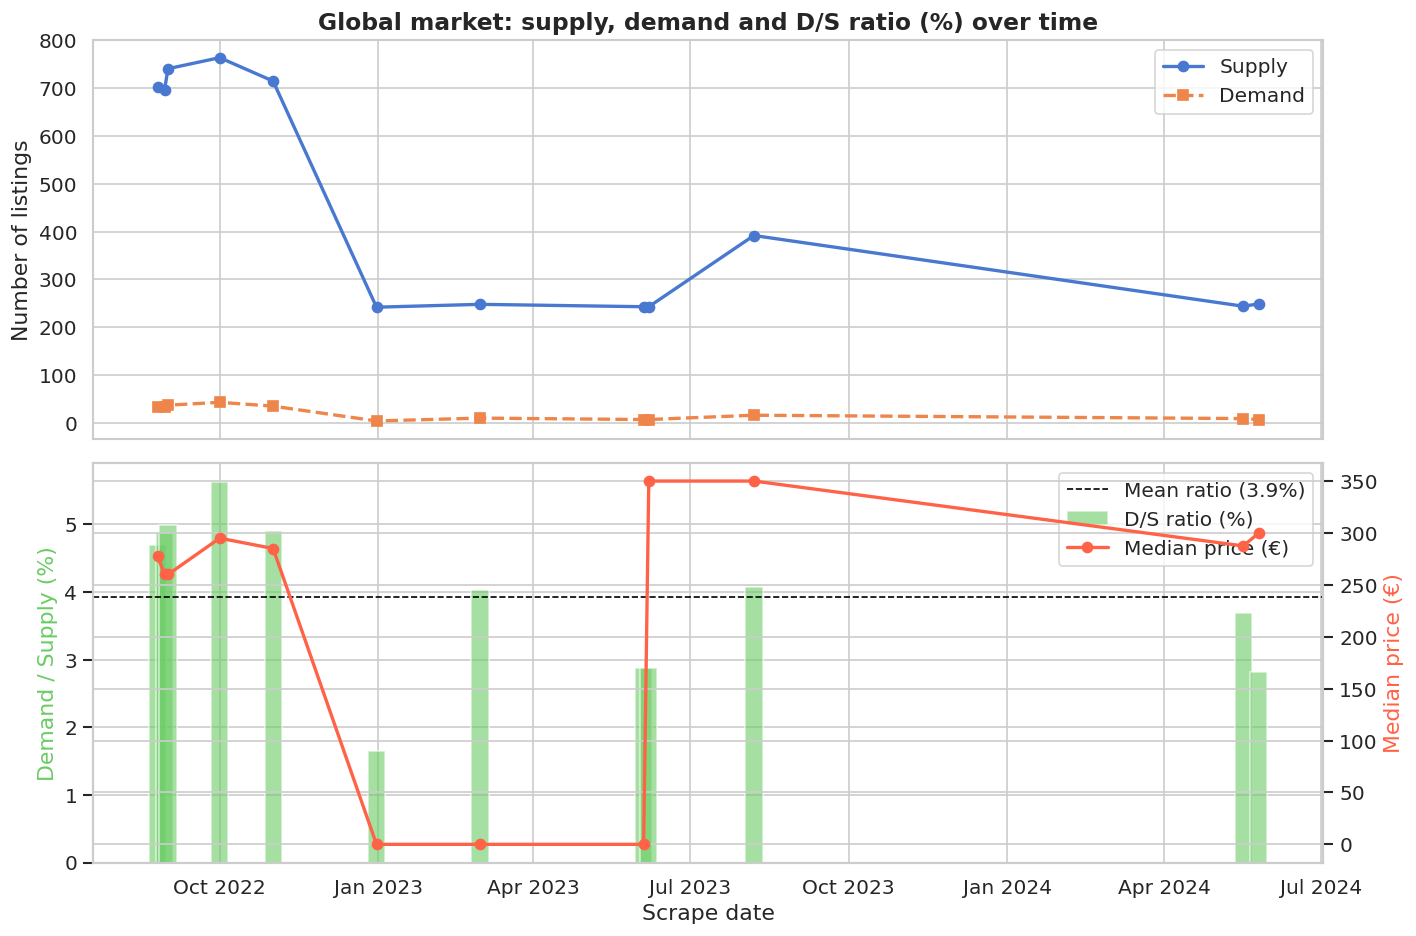

In [29]:
# ── 6a. Global supply, demand and ratio over time ─────────────────────────
global_time = df.groupby('date_scrapped').agg(
    supply    = ('is_supply', 'sum'),
    demand    = ('is_demand', 'sum'),
    med_price = ('price', 'median')
).reset_index()

# Express as percentage, consistent with city_agg and time_city
global_time['sd_ratio'] = (global_time['demand'] / global_time['supply'].replace(0, np.nan)) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: supply and demand volumes
ax1.plot(global_time['date_scrapped'], global_time['supply'], marker='o',
         label='Supply', color=sns.color_palette('muted')[0], linewidth=2)
ax1.plot(global_time['date_scrapped'], global_time['demand'], marker='s',
         label='Demand', color=sns.color_palette('muted')[1], linewidth=2, linestyle='--')
ax1.set_ylabel('Number of listings')
ax1.set_title('Global market: supply, demand and D/S ratio (%) over time',
              fontsize=14, fontweight='bold')
ax1.legend()

# Bottom: ratio (%) + price — reference line at mean ratio
ax3 = ax2.twinx()
ax2.bar(global_time['date_scrapped'], global_time['sd_ratio'],
        width=10, color=sns.color_palette('muted')[2], alpha=0.6, label='D/S ratio (%)')
ax3.plot(global_time['date_scrapped'], global_time['med_price'],
         color='tomato', marker='o', linewidth=2, label='Median price (€)')
ax2.axhline(global_time['sd_ratio'].mean(), color='black', linestyle='--',
            linewidth=1, label=f"Mean ratio ({global_time['sd_ratio'].mean():.1f}%)")
ax2.set_ylabel('Demand / Supply (%)', color=sns.color_palette('muted')[2])
ax3.set_ylabel('Median price (€)', color='tomato')
ax2.set_xlabel('Scrape date')
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2 + lines3, labels2 + labels3, loc='upper right')

plt.tight_layout()
savefig('25_global_supply_demand_ratio_price')

## 7. `seen` as passive demand proxy

Saved → ../reports/figures/26_seen_vs_price_by_city.png


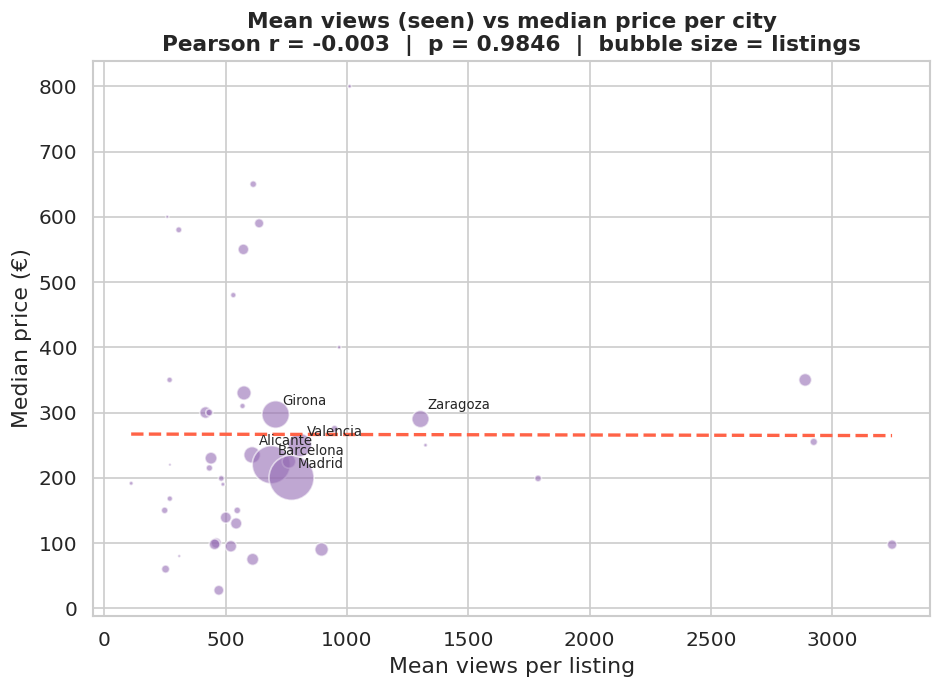

In [30]:
# ── 7a. Seen vs price by city ─────────────────────────────────────────────
seen_city = df.groupby('city').agg(
    mean_seen = ('seen', 'mean'),
    med_price = ('price', 'median'),
    total     = ('seen', 'count')
).reset_index().dropna()
seen_city = seen_city[seen_city['total'] >= MIN_SUPPLY]

r2, p2 = stats.pearsonr(seen_city['mean_seen'], seen_city['med_price'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(seen_city['mean_seen'], seen_city['med_price'],
           s=seen_city['total'] * 0.5, alpha=0.6,
           color=sns.color_palette('muted')[4], edgecolors='white')

m2, b2 = np.polyfit(seen_city['mean_seen'], seen_city['med_price'], 1)
x2 = np.linspace(seen_city['mean_seen'].min(), seen_city['mean_seen'].max(), 100)
ax.plot(x2, m2 * x2 + b2, color='tomato', linewidth=2, linestyle='--')

for _, row in seen_city.nlargest(6, 'total').iterrows():
    ax.annotate(row['city'], (row['mean_seen'], row['med_price']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_title(f'Mean views (seen) vs median price per city\n'
             f'Pearson r = {r2:.3f}  |  p = {p2:.4f}  |  bubble size = listings',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean views per listing')
ax.set_ylabel('Median price (€)')
savefig('26_seen_vs_price_by_city')

## 8. Summary findings

In [ ]:
print('=' * 60)
print('SUPPLY / DEMAND ANALYSIS — KEY FINDINGS')
print('=' * 60)

print(f'\nTotal supply listings : {df["is_supply"].sum():,}')
print(f'Total demand listings : {df["is_demand"].sum():,}')
print(f'Global D/S ratio      : {df["is_demand"].sum() / df["is_supply"].sum() * 100:.2f}%')

print('\n── Top 5 cities with highest D/S ratio (most active demand) ──')
print(city_agg.nlargest(5, 'sd_ratio')[['city','supply','demand','sd_ratio','med_price']]
      .rename(columns={'sd_ratio':'D/S (%)'}).to_string(index=False))

print('\n── Top 5 cities with lowest D/S ratio (active demand only) ───')
print(city_agg[city_agg['demand'] > 0].nsmallest(5, 'sd_ratio')[['city','supply','demand','sd_ratio','med_price']]
      .rename(columns={'sd_ratio':'D/S (%)'}).to_string(index=False))

print(f'\n── D/S ratio (%) vs median price correlation ──────────────')
print(f'Pearson r = {r:.3f}  |  p-value = {p:.4f}')
if p < 0.05:
    direction = 'positive' if r > 0 else 'negative'
    print(f'→ Statistically significant {direction} correlation.')
    if r > 0:
        print('→ Cities with higher D/S ratio tend to have higher median prices.')
    else:
        print('→ Cities with higher D/S ratio tend to have lower median prices.')
else:
    print('→ No statistically significant linear relationship found.')
    print(f'   (r = {r:.3f} suggests a weak {"negative" if r < 0 else "positive"} trend, but p = {p:.4f} > 0.05)')

print(f'\n── Seen (views) vs median price correlation ───────────────')
print(f'Pearson r = {r2:.3f}  |  p-value = {p2:.4f}')
if p2 < 0.05:
    direction2 = 'positive' if r2 > 0 else 'negative'
    print(f'→ Statistically significant {direction2} correlation.')
    if r2 > 0:
        print('→ Cities where listings receive more views tend to have higher median prices.')
    else:
        print('→ Cities where listings receive more views tend to have lower median prices.')
else:
    print('→ No statistically significant linear relationship found.')
    print(f'   (r = {r2:.3f} suggests a weak {"negative" if r2 < 0 else "positive"} trend, but p = {p2:.4f} > 0.05)')

new_figs = [f for f in sorted(os.listdir(FIGURES_DIR)) if f[:2] in ['19','20','21','22','23','24','25','26','27']]
print(f'\n── Figures saved ({len(new_figs)}) ─────────────────────────────')
for f in new_figs:
    print(f'  {f}')